# Aula 1 — Carregando um arquivo CSV no Google Colab para análise de dados em Física

Neste primeiro exemplo, vamos aprender a:

- carregar um arquivo `.csv` no Google Colab;
- ler os dados com a biblioteca `pandas`;
- visualizar as primeiras linhas da tabela;
- verificar informações gerais do conjunto de dados;
- criar um gráfico simples;
- interpretar o significado físico dos dados.

## Contexto físico

O arquivo contém dados simulados de **MRUV (Movimento Retilíneo Uniformemente Variado)**, com 200 pontos experimentais.

As colunas são:

- **ponto**: índice da medição;
- **tempo_s**: tempo em segundos;
- **posicao_m**: posição em metros.

O caminho do arquivo que vamos usar é:

```python
/content/drive/MyDrive/Colab Notebooks/dados_fisica_mruv_200_pontos.csv
```

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Importando as bibliotecas

Nesta etapa, vamos importar as bibliotecas principais:

- `pandas`: para ler e manipular tabelas;
- `matplotlib.pyplot`: para criar gráficos.

Essas duas bibliotecas já são muito usadas em ciência de dados, física experimental e análise numérica.

In [3]:
# Importação das bibliotecas principais
import pandas as pd
import matplotlib.pyplot as plt

## 2. Definindo o caminho do arquivo

Aqui colocamos o caminho exato do arquivo `.csv` no Google Drive.

Como o arquivo já está em uma pasta do Colab Notebooks no seu Drive, basta informar o caminho corretamente.

In [4]:
# Caminho do arquivo CSV no Google Drive
caminho_arquivo = "/content/drive/MyDrive/Colab Notebooks/dados_fisica_mruv_200_pontos.csv"

# Exibindo o caminho para conferência
print("Caminho definido:")
print(caminho_arquivo)

Caminho definido:
/content/drive/MyDrive/Colab Notebooks/dados_fisica_mruv_200_pontos.csv


## 3. Lendo o arquivo CSV

Agora usamos `pd.read_csv()` para carregar o arquivo e transformá-lo em um **DataFrame**.

Um **DataFrame** é uma tabela organizada em linhas e colunas, muito útil para análise de dados.

In [5]:
# Leitura do arquivo CSV
df = pd.read_csv(caminho_arquivo)

# Exibindo mensagem de confirmação
print("Arquivo carregado com sucesso.")

Arquivo carregado com sucesso.


## 4. Visualizando as primeiras linhas

O comando `head()` mostra as primeiras linhas da tabela.

Isso é importante para verificar:

- se o arquivo foi lido corretamente;
- se os nomes das colunas estão corretos;
- se os valores fazem sentido.

In [6]:
# Mostrando as 5 primeiras linhas
df.head()

,ponto,tempo_s,posicao_m
0,1,0.0,0.450
1,2,0.1,0.563
2,3,0.2,0.717
3,4,0.3,1.142
4,5,0.4,0.999


## 5. Visualizando as últimas linhas

Também é útil olhar o final da tabela para verificar como os dados terminam.

In [7]:
# Mostrando as 5 últimas linhas
df.tail()

,ponto,tempo_s,posicao_m
195,196,19.5,176.243
196,197,19.6,177.577
197,198,19.7,179.341
198,199,19.8,181.742
199,200,19.9,182.781


## 6. Informações gerais sobre o conjunto de dados

O comando `info()` mostra:

- número de linhas;
- número de colunas;
- nome das colunas;
- tipo de dado de cada coluna.

Isso ajuda a entender a estrutura do arquivo.

In [8]:
# Informações gerais do DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ponto      200 non-null    int64  
 1   tempo_s    200 non-null    float64
 2   posicao_m  200 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 4.8 KB


## 7. Estatísticas descritivas básicas

O comando `describe()` gera algumas medidas estatísticas importantes, como:

- média;
- desvio padrão;
- valor mínimo;
- valor máximo;
- quartis.

Essas informações são muito úteis para uma análise inicial dos dados.

In [9]:
# Estatísticas descritivas
df.describe()

,ponto,tempo_s,posicao_m
count,200.000000,200.000000,200.000000
mean,100.500000,9.950000,65.414660
std,57.879185,5.787918,54.375022
min,1.000000,0.000000,0.450000
25%,50.750000,4.975000,16.185250
50%,100.500000,9.950000,52.258000
75%,150.250000,14.925000,107.855750
max,200.000000,19.900000,182.781000


## 8. Acessando colunas específicas

Aqui mostramos como acessar uma coluna da tabela.

Isso será útil quando quisermos fazer gráficos ou cálculos.

In [10]:
# Acessando cada coluna separadamente
tempo = df["tempo_s"]
posicao = df["posicao_m"]

print("Primeiros valores de tempo:")
print(tempo.head())

print("\nPrimeiros valores de posição:")
print(posicao.head())

Primeiros valores de tempo:
0    0.0
1    0.1
2    0.2
3    0.3
4    0.4
Name: tempo_s, dtype: float64

Primeiros valores de posição:
0    0.450
1    0.563
2    0.717
3    1.142
4    0.999
Name: posicao_m, dtype: float64


## 9. Fazendo o primeiro gráfico: posição em função do tempo

Agora vamos criar um gráfico de:

$$
\text{{posição}} \times \text{{tempo}}
$$

Em física, esse é um gráfico fundamental para estudar o movimento.

### Interpretação esperada

Como os dados representam um MRUV, a tendência é que a posição varie de forma **não linear** com o tempo, geralmente seguindo um comportamento parabólico.

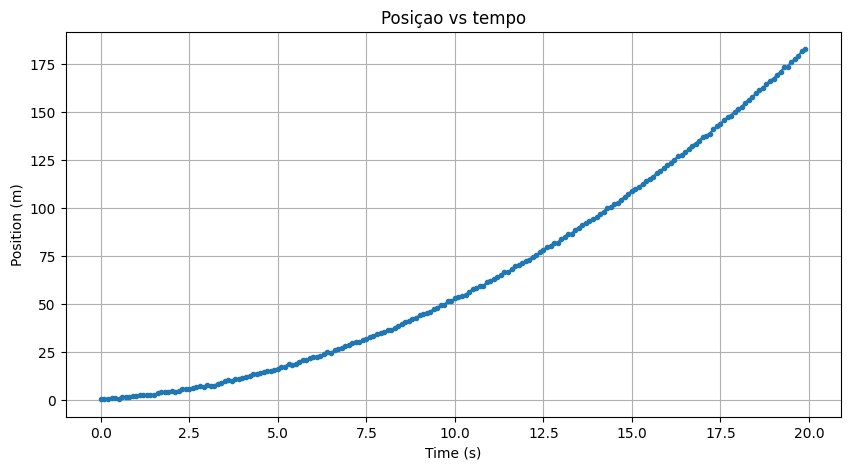

In [12]:
# Criando o gráfico posição versus tempo
plt.figure(figsize=(10, 5))
plt.plot(df["tempo_s"], df["posicao_m"], marker='o', linestyle='-', markersize=3)

# Configurações do gráfico
plt.title("Posiçao vs tempo")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.grid(True)

# Exibindo o gráfico
plt.show()

## 10. Observando a relação física entre posição e tempo

No MRUV, a equação da posição é dada por:

$$
s(t) = s_0 + v_0 t + \frac{{1}}{{2}} a t^2
$$

onde:

- $s(t)$ é a posição;
- $s_0$ é a posição inicial;
- $v_0$ é a velocidade inicial;
- $a$ é a aceleração;
- $t$ é o tempo.

Isso significa que, quando a aceleração é constante, o gráfico de posição versus tempo tende a apresentar uma **curva parabólica**.

## 11. Fazendo um gráfico de dispersão

Outra forma de visualizar os dados é com um gráfico de dispersão.

Esse tipo de gráfico mostra cada ponto experimental individualmente.

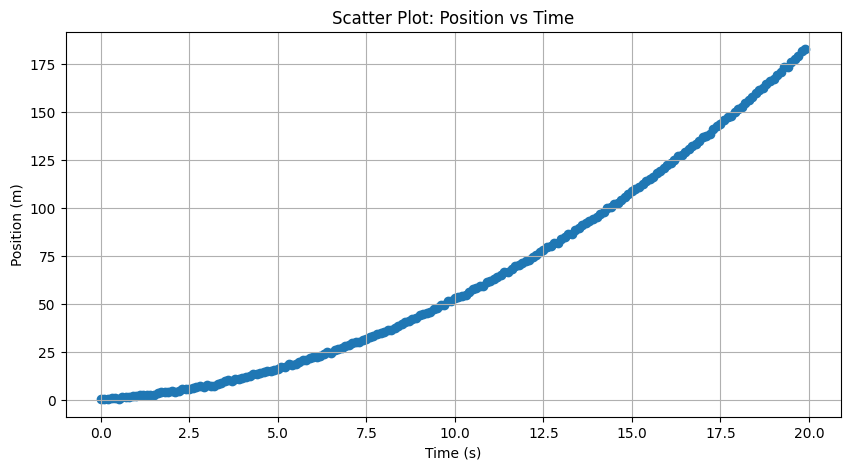

In [13]:
# Gráfico de dispersão
plt.figure(figsize=(10, 5))
plt.scatter(df["tempo_s"], df["posicao_m"])

plt.title("Scatter Plot: Position vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.grid(True)

plt.show()

## 12. Verificando a quantidade de pontos

Como este arquivo foi construído com 200 pontos, podemos conferir isso diretamente no DataFrame.

In [14]:
# Número de linhas e colunas
print("Formato do DataFrame:", df.shape)
print("Número de pontos experimentais:", len(df))

Formato do DataFrame: (200, 3)
Número de pontos experimentais: 200


## 13. Sugestões de discussão em sala

Você pode usar este exemplo para conversar com os alunos sobre:

1. O que é um arquivo CSV.
2. A diferença entre linha e coluna.
3. O que é um DataFrame.
4. Como visualizar rapidamente os dados.
5. Como transformar uma tabela em gráfico.
6. Como ligar o gráfico à equação física do movimento.

## Perguntas que podem ser feitas aos alunos

- O que cada coluna representa fisicamente?
- O gráfico parece linear ou curvo?
- O que isso sugere sobre o tipo de movimento?
- Se fosse MRU, como seria a forma do gráfico?

## 14. Exercício simples para os alunos

Peça para os alunos fazerem as seguintes modificações:

- mostrar as 10 primeiras linhas usando `head(10)`;
- calcular o valor máximo da posição;
- calcular o valor mínimo do tempo;
- criar novamente o gráfico mudando o tamanho da figura;
- trocar o gráfico de linha por gráfico de dispersão.

### Exemplo de desafio extra

Pedir para os alunos responderem:

**Em que intervalo de tempo a posição cresce mais rapidamente?**

In [15]:
# Exemplos simples de exploração que os alunos podem testar

print("Maior posição medida:", df["posicao_m"].max())
print("Menor tempo medido:", df["tempo_s"].min())
print("Maior tempo medido:", df["tempo_s"].max())

Maior posição medida: 182.781
Menor tempo medido: 0.0
Maior tempo medido: 19.9


## 15. Conclusão

Neste primeiro notebook, aprendemos a:

- carregar um arquivo CSV no Colab;
- ler dados com `pandas`;
- inspecionar a tabela;
- obter estatísticas básicas;
- construir gráficos;
- fazer uma primeira interpretação física dos resultados.

No próximo exemplo, podemos avançar para:

- cálculo de velocidade média;
- ajuste polinomial;
- comparação entre MRU e MRUV;
- leitura de arquivos com mais colunas experimentais.